# Recent supernova

```Author: Francisco Förster, modifications: Kay Medina, Alejandra Muñoz-Arancibia. Last updated: 20260625```

**WARNING**: This notebook needs to be updated. Under construction now...

Select only fast rising recent supernova, discard candidates too close to the ecliptic or the MW plane, or which have a very large galactic extinction. Also discard candidates which have a high bogus probability (own, or rb or drb).

*It is highly recommended that you try this notebook in Google Colab using the following [link](https://colab.research.google.com/github/alercebroker/usecases/blob/master/notebooks/ZTF/ALeRCE_SN_Fast.ipynb).*
This will avoid you from having to sort out library installation problems and focus on the contents of the tutorial. You can try installing the dependencies later in your own system.

### Load libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import io
from astropy import coordinates
from astropy.table import Table
from astropy.time import Time
from datetime import datetime
from IPython.display import HTML
from ipywidgets import Layout, Box, widgets
from IPython.display import HTML

In [2]:
from matplotlib.cm import viridis

ALeRCE client

In [3]:
#!pip install alerce
from alerce.core import Alerce
client = Alerce()

PyVO https://pyvo.readthedocs.io/en/latest/

In [4]:
#!pip install pyvo
import pyvo

Astroquery

In [ ]:
#!pip install astroquery

Datashader

In [ ]:
#!pip install datashader

Use [ephem](https://pypi.org/project/ephem/) (install with `pip install ephem`; the legacy `pyephem` alias fails to build on modern setuptools)

In [5]:
#!pip install ephem
import ephem

### TAP connection setup

Instead of using a direct PostgreSQL connection, we connect to the ALeRCE ZTF legacy database using Astronomical Data Query Language ([ADQL](https://www.ivoa.net/documents/ADQL/)) queries to the ALeRCE TAP service, returning results as pandas dataframes. Database table names are prefixed with `ztf.` (e.g. `ztf.object`, `ztf.detection`, etc.).

In [6]:
TAP_URL = "https://tap.alerce.online/tap"
tap_service = pyvo.dal.TAPService(TAP_URL)

def tap_query(query, maxrec=10_000_000):
    result = tap_service.search(query, maxrec=maxrec)
    return result.to_table().to_pandas()

def tap_query_idlist(query, index, maxrec=10_000_000):
    # Upload oid (or other identifier fields) list as a TAP table.
    # IMPORTANT: call the upload column something other than "oid", as "oid" collides
    # with PostgreSQL's system column and breaks the join ("objectid" works)
    col = 'objectid'
    oid_table = Table({col: index})
    result = tap_service.search(query, uploads={'mylist': oid_table},
                                maxrec=maxrec).to_table().to_pandas()
    if col in result.columns:
        result.drop(columns=[col], inplace=True)
    return result

def tap_query_arraycol(query, maxrec=10_000_000):
    # Use this for tables with ARRAY columns (e.g. ztf.taxonomy.classes):
    # the default VOTable parser rejects DaCHS's arraysize="*x*"
    result = tap_service.create_query(query, maxrec=maxrec, responseformat='csv')
    return pd.read_csv(io.BytesIO(result.execute_stream().read()))

In [7]:
# List available ZTF tables via TAP_SCHEMA
query = """
SELECT table_name
FROM TAP_SCHEMA.tables
WHERE schema_name = 'ztf'
ORDER BY table_name
"""
tables = tap_query(query)
tables

,table_name
0,ztf.allwise
1,ztf.dataquality
2,ztf.detection
3,ztf.feature
4,ztf.feature_version
5,ztf.forced_photometry
6,ztf.gaia_ztf
7,ztf.magstat
8,ztf.non_detection
9,ztf.object


In [8]:
# List columns for all ZTF tables via a single TAP_SCHEMA query
query = """
SELECT table_name, column_name, datatype
FROM TAP_SCHEMA.columns
WHERE table_name LIKE 'ztf.%'
ORDER BY table_name, column_name
"""
dftab = tap_query(query)
dftab["table"] = dftab["table_name"].str.replace("ztf.", "", regex=False)
pd.options.display.max_rows = 999
display(dftab[["table", "column_name", "datatype"]])
pd.options.display.max_rows = 101

,table,column_name,datatype
0,allwise,dec,double
1,allwise,h_m_2mass,double
2,allwise,h_msig_2mass,double
3,allwise,j_m_2mass,double
4,allwise,j_msig_2mass,double
5,allwise,k_m_2mass,double
6,allwise,k_msig_2mass,double
7,allwise,oid_catalog,char
8,allwise,ra,double
9,allwise,w1mpro,double


In [9]:
# Available classifiers and versions in the ZTF legacy database.
query = "SELECT * FROM ztf.taxonomy ORDER BY classifier_name"
classes = tap_query_arraycol(query)
classes

,classifier_name,classifier_version,classes
0,lc_classifier,hierarchical_random_forest_1.0.0,"['SNIa', 'SNIbc', 'SNII', 'SLSN', 'QSO', 'AGN'..."
1,LC_classifier_ATAT_forced_phot(beta),beta,"['SNIa', 'SNIbc', 'SNIIb', 'SNII', 'SNIIn', 'S..."
2,lc_classifier_BHRF_forced_phot,2.1.0,"['SNIa', 'SESN', 'SNII', 'SNIIn', 'SLSN', 'TDE..."
3,LC_classifier_BHRF_forced_phot(beta),beta,"['SNIa', 'SNIbc', 'SNIIb', 'SNII', 'SNIIn', 'S..."
4,lc_classifier_BHRF_forced_phot_periodic,2.1.0,"['LPV', 'EA', 'EB/EW', 'Periodic-Other', 'RSCV..."
5,lc_classifier_BHRF_forced_phot_stochastic,2.1.0,"['Microlensing', 'QSO', 'AGN', 'Blazar', 'YSO'..."
6,lc_classifier_BHRF_forced_phot_top,2.1.0,"['Transient', 'Stochastic', 'Periodic']"
7,lc_classifier_BHRF_forced_phot_transient,2.1.0,"['SNIa', 'SESN', 'SNII', 'SNIIn', 'SLSN', 'TDE']"
8,lc_classifier_periodic,hierarchical_random_forest_1.0.0,"['LPV', 'E', 'DSCT', 'RRL', 'CEP', 'Periodic-O..."
9,lc_classifier_stochastic,hierarchical_random_forest_1.0.0,"['QSO', 'AGN', 'Blazar', 'CV/Nova', 'YSO']"


### Query objects which appeared during the last xx days, which are classified as supernova by the stamp classifier with a probability greater than 0.5 or which have more than one detection

In [10]:
ndays = 20
mjd_last = Time(datetime.utcnow(), scale='utc').mjd - ndays

query = '''
SELECT
    o.oid, o.meanra, o.meandec, o.firstmjd,
    o.ndet, p.probability
FROM
    ztf.object AS o
INNER JOIN
    ztf.probability AS p
ON
    o.oid = p.oid
WHERE
    o.firstmjd > %s
    AND p.classifier_name = 'stamp_classifier'
    AND p.class_name = 'SN'
    AND p.ranking = 1
    AND (p.probability > 0.5
        OR o.ndet > 1)
''' % (mjd_last)

sn = tap_query(query)
sn.set_index('oid', inplace=True)
print(sn.shape)
sn.head()

(466, 5)


,meanra,meandec,firstmjd,ndet,probability
oid,,,,,
ZTF26abbdodz,248.979590,1.887230,61197.270718,3,0.502860
ZTF26abaavvu,295.621303,8.323421,61197.358137,2,0.490533
ZTF26abbfzmg,274.650225,-13.392722,61197.401424,2,0.464421
ZTF20abwuzps,270.419638,-18.333605,61197.401887,2,0.446834
ZTF26abdvbir,266.236580,2.106779,61197.403310,5,0.367318


Text(0.5, 0, 'firstmjd')

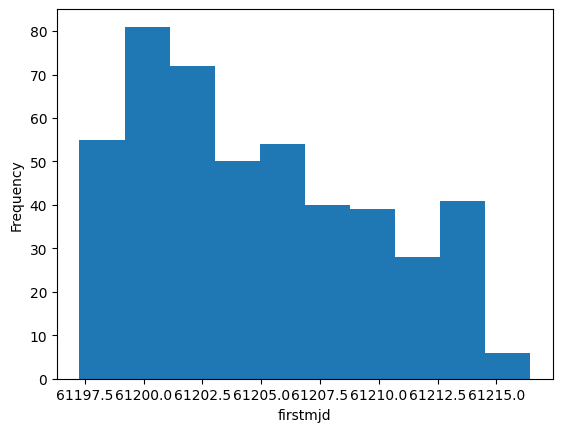

In [11]:
fig, ax = plt.subplots()
sn.firstmjd.plot.hist(ax=ax)
ax.set_xlabel("firstmjd")

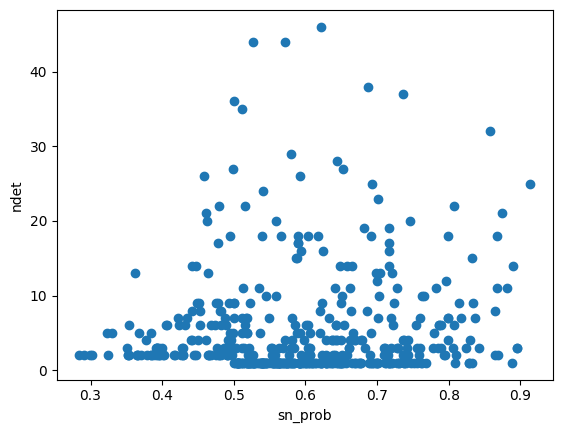

In [12]:
fig, ax = plt.subplots()
ax.set_xlabel("sn_prob")
ax.set_ylabel("ndet")
ax.scatter(sn.probability, sn.ndet);

### Refine search, get first detections if not close to a star and not a bogus according to rb

In [13]:
query = '''
SELECT
    det.oid, det.candid,
    det.drb, det.fid, 
    det.mjd, det.magpsf, det.sigmapsf,
    det.has_stamp,
    ps1.sgscore1, ps1.distpsnr1
FROM
    (SELECT *
    FROM ztf.detection
    WHERE oid in (%s)
    ) as det
    INNER JOIN
    (SELECT *
    FROM ztf.ps1_ztf
    WHERE oid in (%s)
    ) as ps1
    ON det.oid = ps1.oid
''' % (",".join(["'%s'" % oid for oid in sn.index]),
       ",".join(["'%s'" % oid for oid in sn.index]))

detections = tap_query(query)
detections.set_index('oid', inplace=True)
detections.head()

,candid,drb,fid,mjd,magpsf,sigmapsf,has_stamp,sgscore1,distpsnr1
oid,,,,,,,,,
ZTF18aaxjwom,3446245176015015001,0.998761,1,61200.245174,19.524244,0.155529,True,0.004167,0.668266
ZTF18aaxjwom,3446245176015015001,0.998761,1,61200.245174,19.524244,0.155529,True,0.004167,0.788964
ZTF18aaxjwom,3446245176015015001,0.998761,1,61200.245174,19.524244,0.155529,True,0.004167,0.719325
ZTF18aaxjwom,3446245176015015001,0.998761,1,61200.245174,19.524244,0.155529,True,0.004167,0.748411
ZTF18aaxjwom,3446245176015015001,0.998761,1,61200.245174,19.524244,0.155529,True,0.004167,0.844187


### Get non detections after previous filtering

In [14]:
oids = detections.index.unique()

query = '''
SELECT
    oid, mjd, diffmaglim, fid
FROM
    ztf.non_detection AS d
JOIN tap_upload.mylist AS u ON d.oid = u.objectid
'''

non_detections = tap_query_idlist(query, oids)
non_detections.set_index('oid', inplace=True)
non_detections.head()

,mjd,diffmaglim,fid
oid,,,
ZTF18aaxjwom,61171.330069,20.210899,1
ZTF18aaxjwom,61172.327199,20.130100,1
ZTF18aaxjwom,61173.215393,20.112600,1
ZTF18aaxjwom,61175.275845,20.485901,1
ZTF18aaxjwom,61176.274062,20.644100,1


<Axes: ylabel='Frequency'>

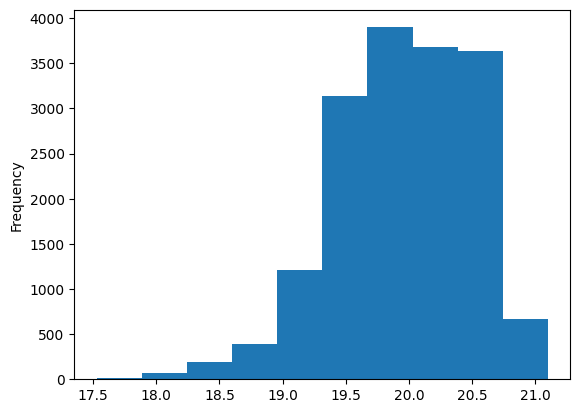

In [15]:
non_detections.diffmaglim.plot.hist()

### Compute dm/dt

In [16]:
def do_dmdt(oid):
    dmdts = []
    dets = detections.loc[oid]
    try: # make sure this is a dataframe and not a series (when only one element)
        dets = dets.to_frame().transpose()
    except:
        True 
    non_dets = non_detections.loc[oid]
    try: # make sure this is a dataframe and not a series (when only one element)
        non_dets = non_dets.to_frame().transpose()
    except:
        True 
    for fid in sorted(dets.fid.unique()):
        if fid == 1:
            fid_str = "g"
        elif fid == 2:
            fid_str = "r"
        else:
            continue
        mask_det = (dets.fid == fid)
        idx_1st_det = dets.loc[mask_det].mjd.astype(float).idxmin()
        mask_non_det = (non_dets.mjd < float(sn.loc[oid].firstmjd)) & (non_dets.fid == fid)
        if mask_non_det.sum() >= 1: # filter must be in both dets and non_dets
            dm = np.array(dets.loc[idx_1st_det].magpsf - non_dets.loc[mask_non_det].diffmaglim)
            dm_error = np.array(dets.loc[idx_1st_det].magpsf + dets.loc[idx_1st_det].sigmapsf \
                                - non_dets.loc[mask_non_det].diffmaglim)
            dt = np.array(dets.loc[idx_1st_det].mjd - non_dets.loc[mask_non_det].mjd)
            dmdt = dm/dt
            dmdt_error = dm_error/dt
            idx_dmdt = np.argmin(dmdt_error) #dmdt = (dm/dt).min()
            dmdt_min = dmdt[idx_dmdt]
            dmdt_error_min = dmdt_error[idx_dmdt]
            newdf = pd.DataFrame(data = {"dmdt_min": [dmdt_min], "dmdt_error": [dmdt_error_min - dmdt_min], \
                                         "dmdt_comp": [dmdt_error_min], 'dt': [dt[idx_dmdt]], 'fid': int(fid), \
                                         'Flag': [dt[idx_dmdt] < 0.5]}, index = [oid])
            dmdts.append(newdf)

    if dmdts == []:
        return None
    else:
        return pd.concat(dmdts)

In [17]:
oids_nd = non_detections.index.unique()
dmdts = []
for oid in oids_nd:
    dmdt = do_dmdt(oid)
    if dmdt is None:
        continue
    else:
        dmdts.append(dmdt)
dmdts = pd.concat(dmdts)
dmdts.head()

,dmdt_min,dmdt_error,dmdt_comp,dt,fid,Flag
ZTF18aaxjwom,-0.128364,0.008642,-0.119722,11.024722,1,False
ZTF18aaxjwom,-17.824356,3.392504,-14.431852,0.045845,2,True
ZTF18abmhlmr,-0.129803,0.066918,-0.062885,3.971424,2,False
ZTF18abqvvsi,-0.109141,0.076896,-0.032245,2.000463,2,False
ZTF18acsyioc,-0.529558,0.145250,-0.384307,0.998056,2,False


<Axes: ylabel='Frequency'>

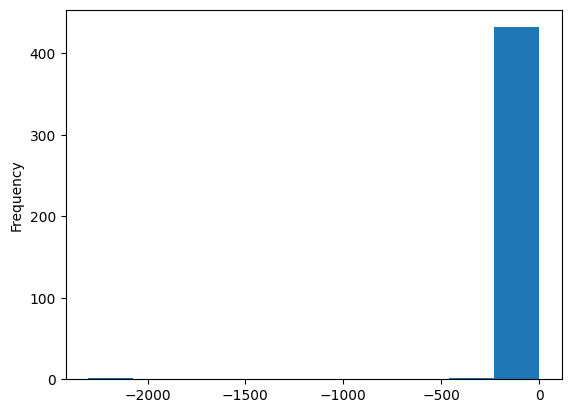

In [18]:
dmdts.dmdt_min.plot.hist()

### Selection criteria: dmdt_min - dmdt_error < threshold (e.g. -0.5 mag / day) and dt > 0.5 (we don't trust those)

In [19]:
# select objects that rise faster than this value in some band
threshold = -0.5 # mag / day
oids = dmdts.loc[(dmdts.dmdt_comp < threshold) & (dmdts.dt > 0.5)].index.unique().tolist()
print(len(oids))
print(oids)

34
['ZTF19abfkamv', 'ZTF19abibzxz', 'ZTF19abtmkiq', 'ZTF20acdleyg', 'ZTF20acoentx', 'ZTF20acxkrcv', 'ZTF20adiprmo', 'ZTF23aaantpy', 'ZTF23aanbqsi', 'ZTF26abamcic', 'ZTF26abaohie', 'ZTF26abbjvuz', 'ZTF26abbwewo', 'ZTF26abcccjk', 'ZTF26abcdnsp', 'ZTF26abcftdg', 'ZTF26abcgcyj', 'ZTF26abcgoxr', 'ZTF26abcjpgt', 'ZTF26abckqsb', 'ZTF26abckrkz', 'ZTF26abclutc', 'ZTF26abcmtur', 'ZTF26abcsehy', 'ZTF26abcselk', 'ZTF26abctotm', 'ZTF26abcwvph', 'ZTF26abcwwgs', 'ZTF26abcxgwh', 'ZTF26abdhmoq', 'ZTF26abdhvzo', 'ZTF26abdmxzk', 'ZTF26abdpvab', 'ZTF26abdqhxm']


<Axes: ylabel='Frequency'>

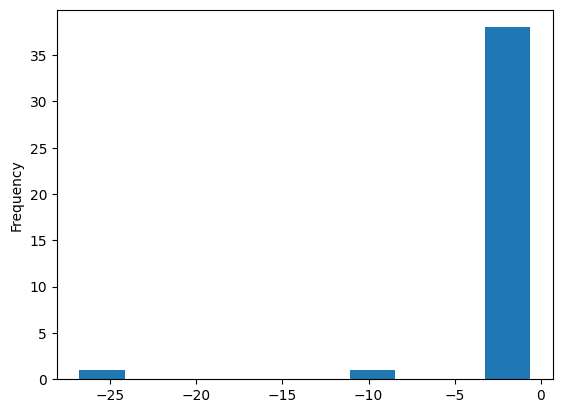

In [20]:
dmdts.loc[oids].dmdt_min.plot.hist()

# Show summary of all tables

In [21]:
sn.loc[oids]

,meanra,meandec,firstmjd,ndet,probability
oid,,,,,
ZTF19abfkamv,275.152733,-19.226261,61211.358588,3,0.390745
ZTF19abibzxz,281.188192,-11.595390,61197.366262,2,0.352566
ZTF19abtmkiq,294.558814,1.943592,61203.442072,1,0.595315
ZTF20acdleyg,276.747874,0.830588,61211.307778,2,0.391372
ZTF20acoentx,298.719696,11.073952,61209.374826,1,0.642067
ZTF20acxkrcv,294.532457,2.806195,61207.421968,1,0.580737
ZTF20adiprmo,279.992305,-8.954708,61210.379699,2,0.426745
ZTF23aaantpy,50.128939,41.509087,61214.477396,2,0.713013
ZTF23aanbqsi,275.841699,14.766459,61210.383021,2,0.299039


In [22]:
detections.loc[oids]

,candid,drb,fid,mjd,magpsf,sigmapsf,has_stamp,sgscore1,distpsnr1
oid,,,,,,,,,
ZTF19abfkamv,3457358580915015021,0.835645,2,61211.358588,19.390793,0.122802,True,0.500000,0.134315
ZTF19abfkamv,3457358580915015021,0.835645,2,61211.358588,19.390793,0.122802,True,0.500000,0.178607
ZTF19abfkamv,3457358580915015021,0.835645,2,61211.358588,19.390793,0.122802,True,0.500000,0.120199
ZTF19abfkamv,3458398020915015037,0.999968,2,61212.398021,19.343489,0.165431,True,0.500000,0.134315
ZTF19abfkamv,3458398020915015037,0.999968,2,61212.398021,19.343489,0.165431,True,0.500000,0.178607
...,...,...,...,...,...,...,...,...,...
ZTF26abdpvab,3460414972915015025,0.999999,1,61214.414977,19.738987,0.121319,True,0.500000,0.349668
ZTF26abdpvab,3460414972915015025,0.999999,1,61214.414977,19.738987,0.121319,True,0.500000,0.259000
ZTF26abdpvab,3460415921615015042,0.999990,1,61214.415926,20.303490,0.216623,True,0.500000,0.349668


In [23]:
non_detections.loc[oids]

,mjd,diffmaglim,fid
oid,,,
ZTF19abfkamv,61183.326875,19.868000,1
ZTF19abfkamv,61184.401134,20.270201,1
ZTF19abfkamv,61185.399167,20.268801,1
ZTF19abfkamv,61186.417917,20.375200,1
ZTF19abfkamv,61195.407859,19.404800,1
...,...,...,...
ZTF26abdqhxm,61210.361551,19.688801,3
ZTF26abdqhxm,61211.445139,20.122200,3
ZTF26abdqhxm,61212.448900,20.337900,3


In [24]:
dmdts.loc[oids]

,dmdt_min,dmdt_error,dmdt_comp,dt,fid,Flag
ZTF19abfkamv,-0.728841,0.125510,-0.603330,0.978414,2,False
ZTF19abibzxz,-1.197846,0.133163,-1.064684,0.964225,1,False
ZTF19abibzxz,-0.801562,0.138278,-0.663284,0.928553,2,False
ZTF19abtmkiq,-0.685049,0.175744,-0.509306,1.000278,2,False
ZTF20acdleyg,-1.088268,0.219202,-0.869066,0.924282,2,False
ZTF20acoentx,-2.014259,0.107548,-1.906711,0.994549,2,False
ZTF20acxkrcv,-1.424458,0.204731,-1.219727,1.026782,2,False
ZTF20adiprmo,-1.456202,0.089542,-1.366660,1.023518,2,False
ZTF23aaantpy,-0.677304,0.122131,-0.555172,0.998831,2,False
ZTF23aanbqsi,-2.849188,0.306979,-2.542209,0.976910,1,False


### Additional test: get galactic and ecliptic coordinates, also extinction in the direction of the object. If extinction too large, probably not a SN. If galactic or ecliptic latitude too small, probably variable star or asteroid, respectively

In [25]:
from astroquery.ipac.irsa.irsa_dust import IrsaDust
import astropy.coordinates as coord
import astropy.units as u

In [26]:
import time

ecl_lat = {}
gal_lat = {}
gal_A_g = {}

for oid in oids:
    #print(oid)
    ra = sn.loc[oid].meanra
    dec = sn.loc[oid].meandec

    # Ecliptic / galactic latitude — computed locally, always works (input is hours, degrees)
    ecl_lat[oid] = np.rad2deg(ephem.Ecliptic(ephem.Equatorial('%s' % (ra / 15.), '%s' % dec, epoch=ephem.J2000)).lat)
    gal_lat[oid] = np.rad2deg(ephem.Galactic(ephem.Equatorial('%s' % (ra / 15.), '%s' % dec, epoch=ephem.J2000)).lat)

    # Galactic extinction (use SFD = D.J. Schlegel, D.P. Finkbeiner, & M. Davis (1998, ApJ, 500, 525))
    coo = coord.SkyCoord(ra, dec, unit='deg', frame='icrs')
    table = IrsaDust.get_extinction_table(coo)
    gal_A_g[oid] = float(table[table["Filter_name"] == "SDSS g"]["A_SFD"][0])

In [27]:
sn_final = pd.concat([sn.loc[oids], pd.DataFrame.from_dict({
                     'ecl_lat': ecl_lat, 'gal_lat': gal_lat, 'gal_A_g': gal_A_g})],
                     axis=1, sort=False)
sn_final

,meanra,meandec,firstmjd,ndet,probability,ecl_lat,gal_lat,gal_A_g
ZTF19abfkamv,275.152733,-19.226261,61211.358588,3,0.390745,4.125834,-2.146913,7.414
ZTF19abibzxz,281.188192,-11.595390,61197.366262,2,0.352566,11.410713,-3.797207,2.998
ZTF19abtmkiq,294.558814,1.943592,61203.442072,1,0.595315,23.122673,-9.491389,1.413
ZTF20acdleyg,276.747874,0.830588,61211.307778,2,0.391372,24.096832,5.817087,6.963
ZTF20acoentx,298.719696,11.073952,61209.374826,1,0.642067,31.236628,-8.691475,1.218
ZTF20acxkrcv,294.532457,2.806195,61207.421968,1,0.580737,23.975893,-9.063404,1.441
ZTF20adiprmo,279.992305,-8.954708,61210.379699,2,0.426745,14.132149,-1.547189,11.032
ZTF23aaantpy,50.128939,41.509087,61214.477396,2,0.713013,22.298669,-13.189638,0.633
ZTF23aanbqsi,275.841699,14.766459,61210.383021,2,0.299039,38.060250,12.789287,0.908
ZTF26abamcic,208.486035,6.957683,61199.300567,14,0.647826,17.425225,64.960557,0.089


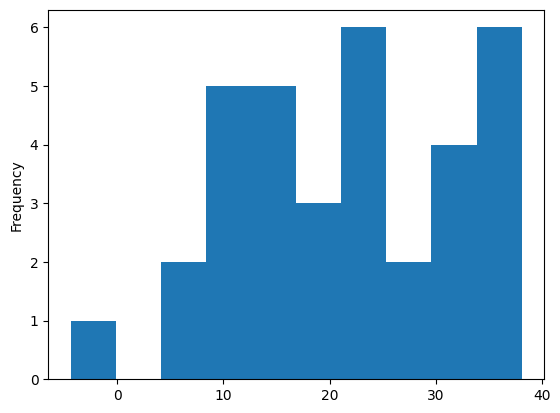

In [28]:
sn_final.ecl_lat.plot.hist();

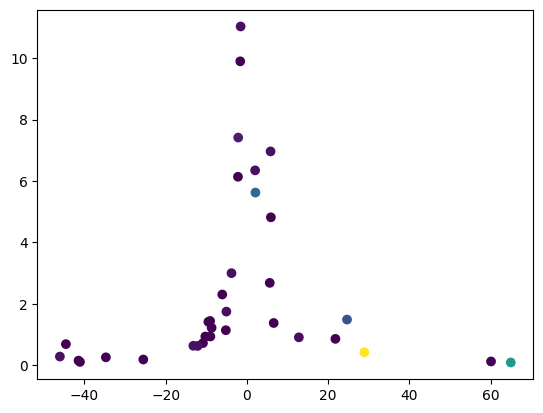

In [29]:
fig, ax = plt.subplots()
ax.scatter(sn_final.gal_lat, sn_final.gal_A_g, c=sn_final.ndet);

### remove everything with |ecliptic latitude| below 20 deg unless it has more than one detection, and with galactic or ecliptic latitude below |20| deg or A_g > 1 mag

In [30]:
mask = ((sn_final.ndet > 1) | (sn_final.ecl_lat > 20)) & (sn_final.gal_lat.abs() > 20) & (sn_final.gal_A_g < 1)

In [31]:
sn_final.loc[mask]

,meanra,meandec,firstmjd,ndet,probability,ecl_lat,gal_lat,gal_A_g
ZTF26abamcic,208.486035,6.957683,61199.300567,14,0.647826,17.425225,64.960557,0.089
ZTF26abcjpgt,252.440140,4.281048,61207.284039,25,0.692557,26.530396,28.907991,0.419
ZTF26abcxgwh,337.622357,0.875661,61211.384699,2,0.397603,9.522876,-46.043186,0.282
ZTF26abdmxzk,263.844768,10.915335,61214.274317,1,0.613443,34.198499,21.781379,0.858


# Generate link to quickly inspect all the candidates

In [32]:
def print_link_ztf(index=None, classifier='stamp_classifier'):
    if len(index) == 1:
        expr = 'https://alerce.online/object/' + index[0]
    else:
        expr1 = 'https://alerce.online/?oid='
        expr2 = '&oid='.join(list(index))
        expr3 = '&selectedClassifier=' + classifier + '&page=1'
        expr = expr1 + expr2 + expr3
    
    display(HTML("<a href='%s' target=\"_blank\"> %s <a>" % (expr, expr)))

In [33]:
oids = sn_final.loc[mask].index
chunk_size = 200
bin_ids = np.arange(int(np.ceil(len(oids) / chunk_size)))
print(str(len(bin_ids)) + ' chunks')
for idx in bin_ids:
    print('Chunk ' + str(idx))

    index_i = idx * chunk_size
    index_f = (idx + 1) * chunk_size
    names = np.array(oids)[index_i:index_f].tolist()
    print_link_ztf(index=names)

1 chunks
Chunk 0


# Plot stamps of final list

In [34]:
for oid in sn_final.loc[mask].index:
    display(HTML("<a href='http://alerce.online/object/%s'> %s <a>" % (oid, oid)))
    display(pd.DataFrame(sn_final.loc[oid]).transpose())
    client.plot_stamps(oid)
    sn.loc[oid]

,meanra,meandec,firstmjd,ndet,probability,ecl_lat,gal_lat,gal_A_g
ZTF26abamcic,208.486035,6.957683,61199.300567,14.0,0.647826,17.425225,64.960557,0.089


,meanra,meandec,firstmjd,ndet,probability,ecl_lat,gal_lat,gal_A_g
ZTF26abcjpgt,252.44014,4.281048,61207.284039,25.0,0.692557,26.530396,28.907991,0.419


,meanra,meandec,firstmjd,ndet,probability,ecl_lat,gal_lat,gal_A_g
ZTF26abcxgwh,337.622357,0.875661,61211.384699,2.0,0.397603,9.522876,-46.043186,0.282


,meanra,meandec,firstmjd,ndet,probability,ecl_lat,gal_lat,gal_A_g
ZTF26abdmxzk,263.844768,10.915335,61214.274317,1.0,0.613443,34.198499,21.781379,0.858


# Plot distribution of dmdt

In [35]:
sn_final.head()

,meanra,meandec,firstmjd,ndet,probability,ecl_lat,gal_lat,gal_A_g
ZTF19abfkamv,275.152733,-19.226261,61211.358588,3,0.390745,4.125834,-2.146913,7.414
ZTF19abibzxz,281.188192,-11.595390,61197.366262,2,0.352566,11.410713,-3.797207,2.998
ZTF19abtmkiq,294.558814,1.943592,61203.442072,1,0.595315,23.122673,-9.491389,1.413
ZTF20acdleyg,276.747874,0.830588,61211.307778,2,0.391372,24.096832,5.817087,6.963
ZTF20acoentx,298.719696,11.073952,61209.374826,1,0.642067,31.236628,-8.691475,1.218


# Plot distribution in the sky

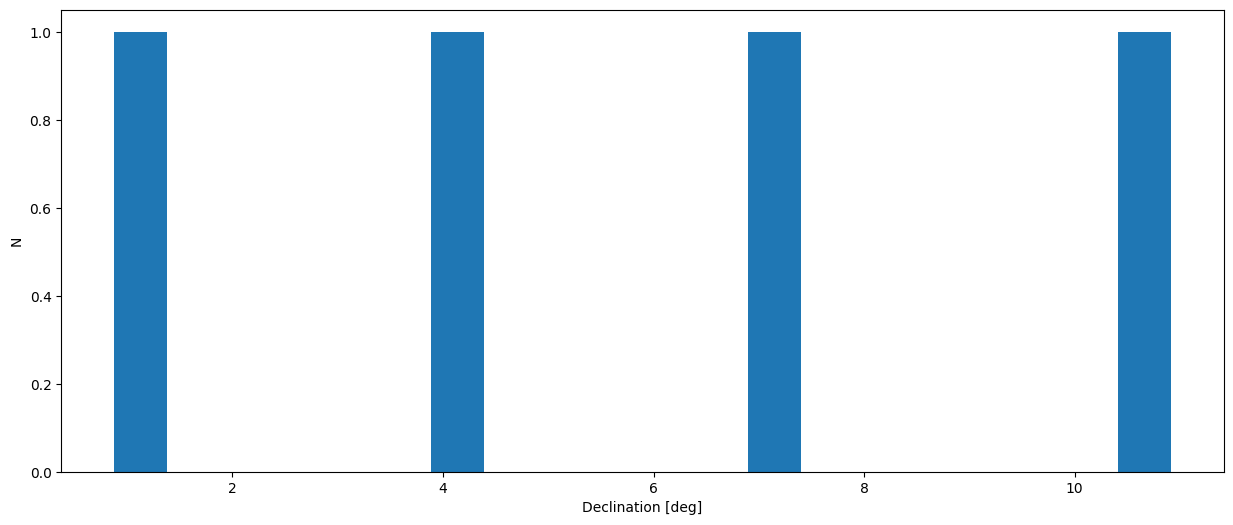

In [36]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.hist(sn_final.loc[mask].meandec, bins=20)
ax.set_xlabel("Declination [deg]")
ax.set_ylabel("N");

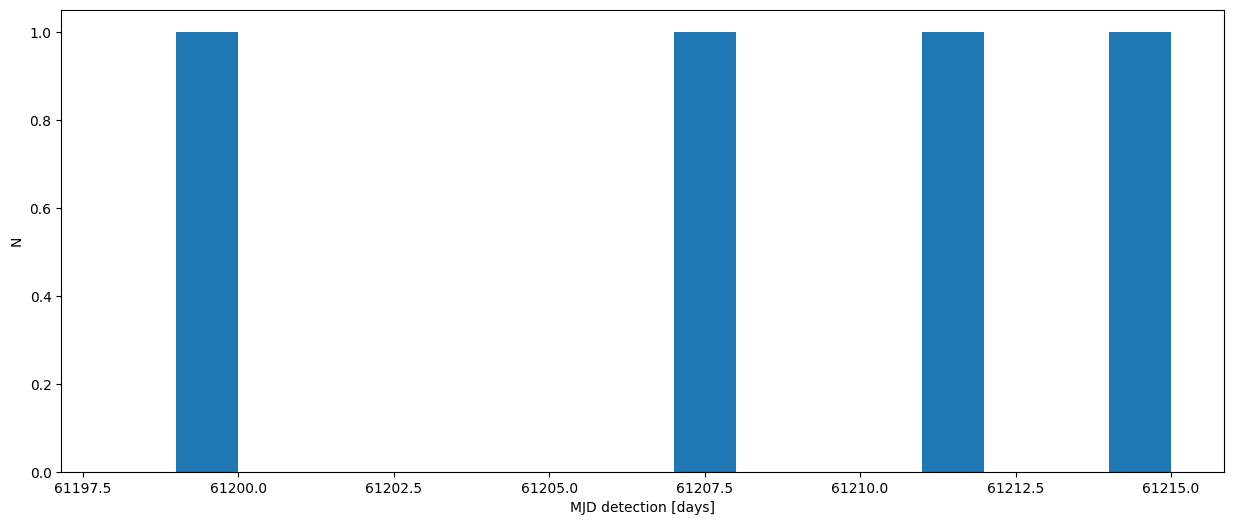

In [37]:
fig, ax = plt.subplots(figsize=(15, 6))
mjd_i = int(sn_final.loc[mask].firstmjd.min() - 1)
mjd_f = int(sn_final.loc[mask].firstmjd.max() + 1)
ax.hist(sn_final.loc[mask].firstmjd, bins=np.linspace(mjd_i, mjd_f, mjd_f - mjd_i + 1))
ax.set_xlabel("MJD detection [days]")
ax.set_ylabel("N");

# Spatial distribution

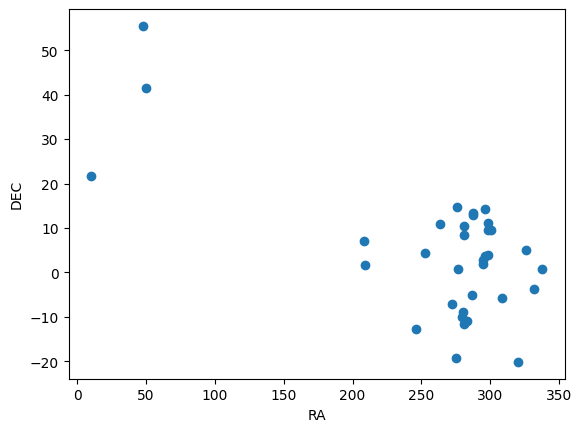

In [38]:
fig, ax = plt.subplots()
ax.scatter(sn_final.meanra,sn_final.meandec)
ax.set_xlabel("RA")
ax.set_ylabel("DEC");

# This is useful if there were lots of candidates to plot

In [39]:
import datashader as ds
import datashader.transfer_functions as tf

4 candidates to plot


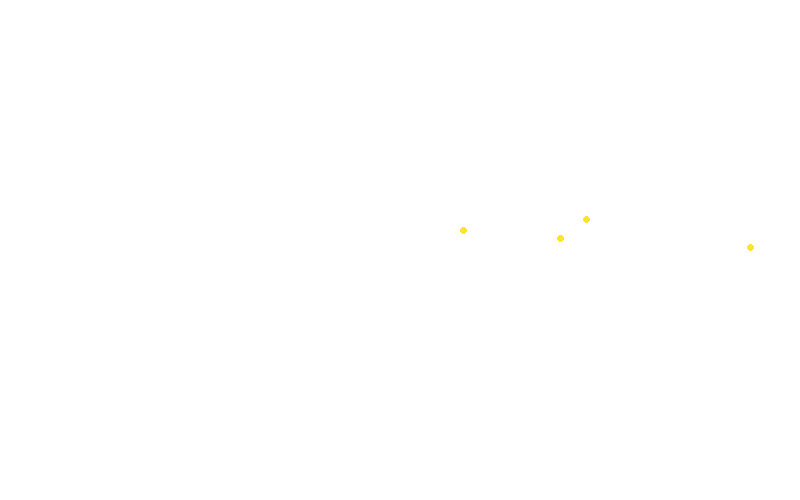

In [40]:
# Static datashader density map of the candidate sky positions.
# NOTES on the migration from the old interactive version:
#  - datashader.bokeh_ext.InteractiveImage was removed in newer datashader; this renders a static image.
#  - For sparse candidate lists, datashader's default how='eq_hist' auto-span divides by zero when every
#    occupied pixel has the same count -> blank image. We use how='linear' with an explicit span, and
#    spread the points so they're visible. (For an interactive pan/zoom version use hvplot/holoviews datashade.)
df = sn_final.loc[mask]
print("%d candidates to plot" % len(df))
cvs = ds.Canvas(plot_width=800, plot_height=500, x_range=(0, 360), y_range=(-90, 90))
agg = cvs.points(df, 'meanra', 'meandec', ds.count())
vmax = float(agg.max())
img = tf.shade(agg, cmap=viridis, how='linear', span=[0, vmax if vmax > 0 else 1])
img = tf.set_background(tf.spread(img, px=3), 'white')
img